Currently this does not pass `loadable_vars` explictly to `vz.open_virtual_mfdataset()`. It is relying on the internal functionality of virtualizarr to identify the 1D coordinate variables that should be passed to `loadable_vars`.  

For reference use Luis' notebook, which also demonstrates how to create VDS references using HTTPS access: https://notebooksharing.space/view/a0214376374af43776a54bf69b0b0308bbc0499fad345fcb5eb70e9ad9cf46c6#displayOptions=

In [1]:
import earthaccess as ea
import xarray as xr
import zarr
from urllib.parse import urlparse
import fsspec
import warnings
import logging

import dask
from dask.distributed import Client, LocalCluster
from coiled import Cluster as CoiledCluster
import numpy as np

import icechunk
import obstore
from obstore.auth.earthdata import NasaEarthdataCredentialProvider # Only S3 links access in-region
from obstore.store import HTTPStore, S3Store
from virtualizarr.parsers import DMRPPParser, NetCDF3Parser, HDFParser
from virtualizarr.registry import ObjectStoreRegistry
import virtualizarr as vz

for _ in (ea, vz, zarr, xr, obstore, dask, fsspec, icechunk):
    print(f"{_.__name__}: {_.__version__}")

earthaccess: 0.16.0
virtualizarr: 2.4.0
zarr: 3.1.5
xarray: 2025.6.1
obstore: 0.8.2
dask: 2024.5.2
fsspec: 2025.7.0
icechunk: 1.1.21


/tmp/ipykernel_1171546/1374992604.py:19: DeprecationWarning: Importing ObjectStoreRegistry from VirtualiZarr is deprecated. Please use 'from obspec_utils.registry import ObjectStoreRegistry instead.
  from virtualizarr.registry import ObjectStoreRegistry


In [2]:
auth = ea.login()

Enter your Earthdata Login username:  deanh808
Enter your Earthdata password:  ········


## 1. Create Dask cluster

In [5]:
cloud_opts = {
    "region": "us-west-2",
    "worker_vm_types": ["t3a.medium"],
    "spot_policy": "spot_with_fallback",
    # "arm": False,
    "name": "test-vd",
    "environ": {"EARTHDATA_TOKEN": auth.token["access_token"]}
}

def create_dask_cluster(environment="local",
                        n_workers=4,
                        cloud_opts={}):
    if environment=="local":
        import logging
        print("Creating new local Dask client")
        cluster = LocalCluster(
            n_workers=n_workers,
            threads_per_worker=1,
            silence_logs=logging.ERROR)
    else:
        print("Creating new Coiled Dask client")
        cluster = CoiledCluster(n_workers=n_workers,
                                **cloud_opts)    

    client = Client(cluster)
    return (client, cluster)

In [6]:
import multiprocessing

# Check how many cpu's are on this VM:
print("CPU count =", multiprocessing.cpu_count())

CPU count = 16


In [7]:
if "client" not in locals() or "cluster" not in locals():
    client, cluster = create_dask_cluster(
        environment="local",
        n_workers=16,
        cloud_opts=cloud_opts)
client

Creating new local Dask client


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: https://cluster-leoks.dask.host/jupyter/proxy/8787/status,
Dashboard: https://cluster-leoks.dask.host/jupyter/proxy/8787/status,Workers: 16
Total threads: 16,Total memory: 60.38 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:39725,Workers: 16
Dashboard: https://cluster-leoks.dask.host/jupyter/proxy/8787/status,Total threads: 16
Started: Just now,Total memory: 60.38 GiB
Comm: tcp://127.0.0.1:45153,Total threads: 1
Dashboard: https://cluster-leoks.dask.host/jupyter/proxy/40035/status,Memory: 3.77 GiB
Nanny: tcp://127.0.0.1:39903,


#### Following code is needed to give EDL creds explicitly to each Dask worker

In [8]:
def silence_worker_warnings_and_auth(token):
    import warnings
    import logging
    # local instance of earthaccess is explicitely authenticated
    import earthaccess as ea
    import os

    if token:
        os.environ["EARTHDATA_TOKEN"]= token
        auth = ea.login(strategy="environment")
    
    warnings.filterwarnings("ignore")
    for name in ["distributed", "xarray", "py.warnings", "fsspec", "h5netcdf", "h5py"]:
        logging.getLogger(name).setLevel(logging.ERROR)

In [9]:
%%capture
client.run(silence_worker_warnings_and_auth, auth.token["access_token"])

## 2. Create multi-collection VDS for all monthly snapshot collections

## 2.1 Create combined VDS ref files for each collection

In [10]:
shortnames_monthly = [
    "SASSIE_ECCO_L4_OBP_SSH_LLC1080GRID_SNAPSHOT_V1R1",
    "SASSIE_ECCO_L4_TEMP_SALINITY_LLC1080GRID_SNAPSHOT_V1R1",
    "SASSIE_ECCO_L4_SEA_ICE_CONC_THICK_VEL_LLC1080GRID_SNAPSHOT_V1R1",
]

In [13]:
%%time

vds_s3_list = []

for sn in shortnames_monthly:
    
    print(sn)

    auth = ea.login()
    
    ## 1. Get granule metadata and s3 links ------------------------------------------------
    results = ea.search_data(
        short_name=sn,
        provider="POCLOUD",
        cloud_hosted=True,
    )
        # S3 links
    granule_data_urls_s3 = [
        granule.data_links(access="direct")[0] for granule in results
    ]
    print("Number of file found: ", len(results))

    
    ## 2. Setup store registry -------------------------------------------------------------
    access = "direct"
    credentials_endpoint = "https://archive.podaac.earthdata.nasa.gov/s3credentials"
        # Get bucket location of granules from the first granule's metadata:
    parsed_url = urlparse(results[0].data_links(access=access)[0])
    bucket = parsed_url.netloc
    
    s3_store = S3Store(
        bucket=bucket,
        region="us-west-2",
        credential_provider=NasaEarthdataCredentialProvider(credentials_endpoint, auth=auth.token["access_token"]),
        virtual_hosted_style_request=False,
        client_options={"allow_http": True},
    )
    s3_obstore_registry = ObjectStoreRegistry({f"s3://{bucket}": s3_store})


    ## 3. Setup any data preprocessing and kwargs to pass to xr.combine_nested() -------------
        # not doing any preprocessing currently:
    def preprocess_func(ds):
        return ds
    
    xr_combine_nested_kwargs = {
        "concat_dim": "time",  # Concatenate files along the time dimension
        "preprocess": preprocess_func, # Normalize the dataframe 
        "data_vars": "minimal",  # Only load data variables that include the concat_dim
        "coords": "minimal",  # Only load coordinate variables that include the concat_dim
        "compat": "override",  # Avoid coordinate conflicts by picking the first
        "combine_attrs": "override",  # Avoid attribute conflicts by picking the first
    }


    ## 4. Create VDS reference - does the single file references and concatentation
    ## in one function ------------------------------------------------------------------------
    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore",
            message="Numcodecs codecs*",
            category=UserWarning,
        )
        group = None
        vds_s3 = vz.open_virtual_mfdataset(
            urls=granule_data_urls_s3,
            registry=s3_obstore_registry,
            parser=HDFParser(),
            decode_times=False,
            parallel="dask",
            combine="nested",
            **xr_combine_nested_kwargs,
        )

    vds_s3_list.append(vds_s3)

SASSIE_ECCO_L4_OBP_SSH_LLC1080GRID_SNAPSHOT_V1R1
Number of file found:  85
SASSIE_ECCO_L4_TEMP_SALINITY_LLC1080GRID_SNAPSHOT_V1R1
Number of file found:  85
SASSIE_ECCO_L4_SEA_ICE_CONC_THICK_VEL_LLC1080GRID_SNAPSHOT_V1R1
Number of file found:  85
CPU times: user 3.62 s, sys: 697 ms, total: 4.32 s
Wall time: 1min 6s


## 2.2 Multi-collection VDS

In [14]:
## Combine all into single VDS:
vds_monthly_composite_s3 = xr.combine_nested(
    vds_s3_list, concat_dim=None, 
    compat='override', combine_attrs='drop_conflicts'
)

In [15]:
vds_monthly_composite_s3

<xarray.Dataset> Size: 124GB
Dimensions:   (time: 85, j: 1080, i: 1800, nb: 4, k: 90, k_u: 90, k_l: 90,
               k_p1: 91, nv: 2, i_g: 1800, j_g: 1080)
Coordinates: (12/22)
  * time      (time) int32 340B 193596 194268 195012 ... 253476 254220 254964
  * j         (j) int32 4kB 0 1 2 3 4 5 6 ... 1073 1074 1075 1076 1077 1078 1079
  * i         (i) int32 7kB 0 1 2 3 4 5 6 ... 1793 1794 1795 1796 1797 1798 1799
    XC        (j, i) float32 8MB ManifestArray<shape=(1080, 1800), dtype=floa...
    YC        (j, i) float32 8MB ManifestArray<shape=(1080, 1800), dtype=floa...
    XC_bnds   (j, i, nb) float32 31MB ManifestArray<shape=(1080, 1800, 4), dt...
    ...        ...
  * j_g       (j_g) int32 4kB 0 1 2 3 4 5 6 ... 1074 1075 1076 1077 1078 1079
  * i_g       (i_g) int32 7kB 0 1 2 3 4 5 6 ... 1794 1795 1796 1797 1798 1799
    XU        (j, i_g) float32 8MB ManifestArray<shape=(1080, 1800), dtype=fl...
    YU        (j, i_g) float32 8MB ManifestArray<shape=(1080, 1800), dtype=fl...
    XV        (j_g, i) float32 8MB ManifestArray<shape=(1080, 1800), dtype=fl...
    YV        (j_g, i) float32 8MB ManifestArray<shape=(1080, 1800), dtype=fl...
Dimensions without coordinates: nb, nv
Data variables:
    ETAN      (time, j, i) float32 661MB ManifestArray<shape=(85, 1080, 1800)...
    PHIBOT    (time, j, i) float32 661MB ManifestArray<shape=(85, 1080, 1800)...
    SALT      (time, k, j, i) float32 59GB ManifestArray<shape=(85, 90, 1080,...
    THETA     (time, k, j, i) float32 59GB ManifestArray<shape=(85, 90, 1080,...
    SIarea    (time, j, i) float32 661MB ManifestArray<shape=(85, 1080, 1800)...
    SIheff    (time, j, i) float32 661MB ManifestArray<shape=(85, 1080, 1800)...
    SIhsnow   (time, j, i) float32 661MB ManifestArray<shape=(85, 1080, 1800)...
    SIuice    (time, j, i_g) float32 661MB ManifestArray<shape=(85, 1080, 180...
    SIvice    (time, j_g, i) float32 661MB ManifestArray<shape=(85, 1080, 180...
    sIceLoad  (time, j, i) float32 661MB ManifestArray<shape=(85, 1080, 1800)...
Attributes: (12/47)
    acknowledgement:                   This research was carried out by the J...
    author:                            Marie Zahn, Mike Wood, Ian Fenty, and ...
    cdm_data_type:                     Grid
    Conventions:                       CF-1.8, ACDD-1.3
    creator_email:                     marie.j.zahn@jpl.nasa.gov
    creator_institution:               NASA Jet Propulsion Laboratory (JPL)
    ...                                ...
    time_coverage_resolution:          PT0S
    geospatial_vertical_max:           0.0
    geospatial_vertical_min:           -7000.0
    geospatial_vertical_positive:      up
    geospatial_vertical_resolution:    variable
    geospatial_vertical_units:         meter

In [16]:
## Modify/add some attributes:
vds_monthly_composite_s3.attrs['time_coverage_start'] = '2014-01-15T00:00:00Z'
vds_monthly_composite_s3.attrs['time_coverage_end'] = '2021-02-08T00:00:00Z'
vds_monthly_composite_s3.attrs['identifier_product_doi'] = "https://doi.org/10.5067/SEL1D-DUG11"
vds_monthly_composite_s3.attrs['date_created'] = "2026-03-21T00:00:00Z"
vds_monthly_composite_s3.attrs['history'] = "Virtual layer on top of the initial release of the ECCO N1 SASSIE Ocean-Sea Ice Simulation data, for all monthly snapshot collections."
vds_monthly_composite_s3.attrs['comment'] = (
    vds_monthly_composite_s3.attrs['comment']
    + " This is a virtual layer on top of the original data, for all monthly snapshot datasets - it allows the user to access all"
    + " the data files from all datasets as if they were in a single, composite dataset."
)

## 2.3 Duplicate to create a VDS with HTTP endpoints

In [20]:
from pathlib import Path

In [21]:
def s3_to_http_url(old_s3_path: str) -> str:
    """
    Change S3 endpoint to HTTP.
    """
    from pathlib import Path

    https_base = "https://archive.podaac.earthdata.nasa.gov/"
    return str(https_base + old_s3_path.split("//")[-1])

In [22]:
vds_monthly_composite_http = vds_monthly_composite_s3.vz.rename_paths(s3_to_http_url)

In [23]:
vds_monthly_composite_http

<xarray.Dataset> Size: 124GB
Dimensions:   (time: 85, j: 1080, i: 1800, nb: 4, k: 90, k_u: 90, k_l: 90,
               k_p1: 91, nv: 2, i_g: 1800, j_g: 1080)
Coordinates: (12/22)
  * time      (time) int32 340B 193596 194268 195012 ... 253476 254220 254964
  * j         (j) int32 4kB 0 1 2 3 4 5 6 ... 1073 1074 1075 1076 1077 1078 1079
  * i         (i) int32 7kB 0 1 2 3 4 5 6 ... 1793 1794 1795 1796 1797 1798 1799
    XC        (j, i) float32 8MB ManifestArray<shape=(1080, 1800), dtype=floa...
    YC        (j, i) float32 8MB ManifestArray<shape=(1080, 1800), dtype=floa...
    XC_bnds   (j, i, nb) float32 31MB ManifestArray<shape=(1080, 1800, 4), dt...
    ...        ...
  * j_g       (j_g) int32 4kB 0 1 2 3 4 5 6 ... 1074 1075 1076 1077 1078 1079
  * i_g       (i_g) int32 7kB 0 1 2 3 4 5 6 ... 1794 1795 1796 1797 1798 1799
    XU        (j, i_g) float32 8MB ManifestArray<shape=(1080, 1800), dtype=fl...
    YU        (j, i_g) float32 8MB ManifestArray<shape=(1080, 1800), dtype=fl...
    XV        (j_g, i) float32 8MB ManifestArray<shape=(1080, 1800), dtype=fl...
    YV        (j_g, i) float32 8MB ManifestArray<shape=(1080, 1800), dtype=fl...
Dimensions without coordinates: nb, nv
Data variables:
    ETAN      (time, j, i) float32 661MB ManifestArray<shape=(85, 1080, 1800)...
    PHIBOT    (time, j, i) float32 661MB ManifestArray<shape=(85, 1080, 1800)...
    SALT      (time, k, j, i) float32 59GB ManifestArray<shape=(85, 90, 1080,...
    THETA     (time, k, j, i) float32 59GB ManifestArray<shape=(85, 90, 1080,...
    SIarea    (time, j, i) float32 661MB ManifestArray<shape=(85, 1080, 1800)...
    SIheff    (time, j, i) float32 661MB ManifestArray<shape=(85, 1080, 1800)...
    SIhsnow   (time, j, i) float32 661MB ManifestArray<shape=(85, 1080, 1800)...
    SIuice    (time, j, i_g) float32 661MB ManifestArray<shape=(85, 1080, 180...
    SIvice    (time, j_g, i) float32 661MB ManifestArray<shape=(85, 1080, 180...
    sIceLoad  (time, j, i) float32 661MB ManifestArray<shape=(85, 1080, 1800)...
Attributes: (12/49)
    acknowledgement:                   This research was carried out by the J...
    author:                            Marie Zahn, Mike Wood, Ian Fenty, and ...
    cdm_data_type:                     Grid
    Conventions:                       CF-1.8, ACDD-1.3
    creator_email:                     marie.j.zahn@jpl.nasa.gov
    creator_institution:               NASA Jet Propulsion Laboratory (JPL)
    ...                                ...
    geospatial_vertical_min:           -7000.0
    geospatial_vertical_positive:      up
    geospatial_vertical_resolution:    variable
    geospatial_vertical_units:         meter
    identifier_product_doi:            https://doi.org/10.5067/SEL1D-DUG11
    date_created:                      2026-03-21T00:00:00Z

## 2.4 Save to Icechunk stores

One store each for the S3 and HTTP endpoints.

In [30]:
## Only works to create icechunk store for s3 endpoints currently -------------------------------

def create_local_icechunk_repo_httpaccess(repo_name: str, vcc_http_base: str):
    """
    Creates an icechunk repository locally, with pointers to data chunks in HTTPS locations.

    Inputs
    ------
    * repo_name (str): path to icechunk repo.
    """
    storage = icechunk.local_filesystem_storage(path=repo_name)
    config = icechunk.RepositoryConfig.default()
    config.set_virtual_chunk_container(
        icechunk.VirtualChunkContainer(
            vcc_http_base,
            icechunk.http_store()
        )
    )
    return icechunk.Repository.create(storage, config)

In [25]:
## Only works to create icechunk store for s3 endpoints currently -------------------------------

def create_local_icechunk_repo_s3access(repo_name: str, vcc_bucket: str):
    """
    Creates an icechunk repository locally, with pointers to data chunks in S3 locations.

    Inputs
    ------
    * repo_name (str): path to icechunk repo.
    """
    storage = icechunk.local_filesystem_storage(path=repo_name)
    config = icechunk.RepositoryConfig.default()
    config.set_virtual_chunk_container(
        icechunk.VirtualChunkContainer(
            url_prefix=vcc_bucket+"/",
            store=icechunk.s3_store(region="us-west-2", anonymous=True)
        )
    )
    return icechunk.Repository.create(storage, config)

#### S3 endpoints

In [39]:
# Create icechunk repo and session
fname_store_s3access = "SASSIE_ECCO_L4_SNAPSHOT_V1R1_ALL_s3.icechunk"
repo = create_local_icechunk_repo_s3access(fname_store_s3access, "s3://"+bucket)
session = repo.writable_session("main")

  2026-03-24T20:42:07.041545Z  WARN icechunk::storage::object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk/src/storage/object_store.rs:92



In [40]:
# Then write to the store:
vds_monthly_composite_s3.virtualize.to_icechunk(session.store)
session.commit("Initial commit.")

'CTH5TKZC93AZF3F9G4Z0'

#### HTTP endpoints

In [41]:
# Create icechunk repo and session
fname_store_httpaccess = "SASSIE_ECCO_L4_SNAPSHOT_V1R1_ALL_https.icechunk"
repo = create_local_icechunk_repo_httpaccess(fname_store_httpaccess, "https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/")
session = repo.writable_session("main")

  2026-03-24T20:42:11.143662Z  WARN icechunk::storage::object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk/src/storage/object_store.rs:92



In [42]:
# Then write to the store:
vds_monthly_composite_http.virtualize.to_icechunk(session.store)
session.commit("Initial commit.")

'K203E1HVKVMYXK8C2510'

In [43]:
!tar -cvf $fname_store_s3access".tar" $fname_store_s3access

SASSIE_ECCO_SNAPSHOT_V1R1_ALL_s3.icechunk/
SASSIE_ECCO_SNAPSHOT_V1R1_ALL_s3.icechunk/transactions/
SASSIE_ECCO_SNAPSHOT_V1R1_ALL_s3.icechunk/transactions/CTH5TKZC93AZF3F9G4Z0
SASSIE_ECCO_SNAPSHOT_V1R1_ALL_s3.icechunk/config.yaml
SASSIE_ECCO_SNAPSHOT_V1R1_ALL_s3.icechunk/chunks/
SASSIE_ECCO_SNAPSHOT_V1R1_ALL_s3.icechunk/chunks/S7P8JCBQ10PMPF1165H0
SASSIE_ECCO_SNAPSHOT_V1R1_ALL_s3.icechunk/chunks/SVRGR56W881J492ZQ270
SASSIE_ECCO_SNAPSHOT_V1R1_ALL_s3.icechunk/chunks/Z729YPM8Y69VDQ424DZ0
SASSIE_ECCO_SNAPSHOT_V1R1_ALL_s3.icechunk/chunks/2V3WG9HYZ9GXVCRQVZZ0
SASSIE_ECCO_SNAPSHOT_V1R1_ALL_s3.icechunk/snapshots/
SASSIE_ECCO_SNAPSHOT_V1R1_ALL_s3.icechunk/snapshots/CTH5TKZC93AZF3F9G4Z0
SASSIE_ECCO_SNAPSHOT_V1R1_ALL_s3.icechunk/snapshots/1CECHNKREP0F1RSTCMT0
SASSIE_ECCO_SNAPSHOT_V1R1_ALL_s3.icechunk/manifests/
SASSIE_ECCO_SNAPSHOT_V1R1_ALL_s3.icechunk/manifests/C02X9GFA18HK2ZTXDTXG
SASSIE_ECCO_SNAPSHOT_V1R1_ALL_s3.icechunk/manifests/CGC0B3EVGKE2RHTRVRW0
SASSIE_ECCO_SNAPSHOT_V1R1_ALL_s3.icechunk/m

In [44]:
!tar -cvf $fname_store_httpaccess".tar" $fname_store_httpaccess

SASSIE_ECCO_SNAPSHOT_V1R1_ALL_https.icechunk/
SASSIE_ECCO_SNAPSHOT_V1R1_ALL_https.icechunk/transactions/
SASSIE_ECCO_SNAPSHOT_V1R1_ALL_https.icechunk/transactions/K203E1HVKVMYXK8C2510
SASSIE_ECCO_SNAPSHOT_V1R1_ALL_https.icechunk/config.yaml
SASSIE_ECCO_SNAPSHOT_V1R1_ALL_https.icechunk/chunks/
SASSIE_ECCO_SNAPSHOT_V1R1_ALL_https.icechunk/chunks/718JBPVNNZZAH39V8Y3G
SASSIE_ECCO_SNAPSHOT_V1R1_ALL_https.icechunk/chunks/5XK43JJ65S6MY0HASB5G
SASSIE_ECCO_SNAPSHOT_V1R1_ALL_https.icechunk/chunks/2N4HT4KYHX6DV955H6WG
SASSIE_ECCO_SNAPSHOT_V1R1_ALL_https.icechunk/chunks/P2CRP0MXWB5EFPAE8MZG
SASSIE_ECCO_SNAPSHOT_V1R1_ALL_https.icechunk/snapshots/
SASSIE_ECCO_SNAPSHOT_V1R1_ALL_https.icechunk/snapshots/1CECHNKREP0F1RSTCMT0
SASSIE_ECCO_SNAPSHOT_V1R1_ALL_https.icechunk/snapshots/K203E1HVKVMYXK8C2510
SASSIE_ECCO_SNAPSHOT_V1R1_ALL_https.icechunk/manifests/
SASSIE_ECCO_SNAPSHOT_V1R1_ALL_https.icechunk/manifests/47W5SE8PXDGK5TP01FA0
SASSIE_ECCO_SNAPSHOT_V1R1_ALL_https.icechunk/manifests/X06XVVW047ARTDN2FHY

## 3. Create multi-collection VDS for all daily mean collections

## 3.1 Create combined VDS ref files for each collection

In [10]:
shortnames_daily = [
    "SASSIE_ECCO_L4_ATM_STATE_LLC1080GRID_DAILY_V1R1",
    "SASSIE_ECCO_L4_FRESH_FLUX_LLC1080GRID_DAILY_V1R1",
    "SASSIE_ECCO_L4_HEAT_FLUX_LLC1080GRID_DAILY_V1R1",
    "SASSIE_ECCO_L4_OBP_SSH_LLC1080GRID_DAILY_V1R1",
    "SASSIE_ECCO_L4_DENS_PRESS_LLC1080GRID_DAILY_V1R1",
    "SASSIE_ECCO_L4_OCN_3D_SALINITY_ADV_FLUX_LLC1080GRID_DAILY_V1R1",
    "SASSIE_ECCO_L4_OCN_3D_SALINITY_DIFF_FLUX_LLC1080GRID_DAILY_V1R1",
    "SASSIE_ECCO_L4_OCN_3D_TEMP_ADV_FLUX_LLC1080GRID_DAILY_V1R1",
    "SASSIE_ECCO_L4_OCN_3D_TEMP_DIFF_FLUX_LLC1080GRID_DAILY_V1R1",
    "SASSIE_ECCO_L4_OCN_3D_VOL_FLUX_LLC1080GRID_DAILY_V1R1",
    "SASSIE_ECCO_L4_OCN_VEL_LLC1080GRID_DAILY_V1R1",
    "SASSIE_ECCO_L4_SEA_ICE_CONC_THICK_VEL_LLC1080GRID_DAILY_V1R1",
    "SASSIE_ECCO_L4_SEA_ICE_VOL_AREA_TEND_LLC1080GRID_DAILY_V1R1",  ## Errors when trying to concat the single refs. Something about a fancy index?
    "SASSIE_ECCO_L4_SEA_ICE_VOL_AREA_FLUX_LLC1080GRID_DAILY_V1R1",  ## Errors when trying to concat the single refs. Something about a fancy index?
    "SASSIE_ECCO_L4_STRESS_LLC1080GRID_DAILY_V1R1",
    "SASSIE_ECCO_L4_TEMP_SALINITY_LLC1080GRID_DAILY_V1R1",
    "SASSIE_ECCO_L4_KPP_DIAGS_LLC1080GRID_DAILY_V1R1",
    "SASSIE_ECCO_L4_KPP_BOUNDARY_LAYER_LLC1080GRID_DAILY_V1R1",
]


shortnames_other = [
    "SASSIE_ECCO_L4_GEOMETRY_LLC1080GRID_V1R1"    
]

In [13]:
vds_s3_list = []

In [ ]:
%%time

for sn in shortnames_daily[:13]:
    
    print(sn)

    auth = ea.login()
    
    ## 1. Get granule metadata and s3 links ------------------------------------------------
    results = ea.search_data(
        short_name=sn,
        provider="POCLOUD",
        cloud_hosted=True,
    )
        # S3 links
    granule_data_urls_s3 = [
        granule.data_links(access="direct")[0] for granule in results
    ]
    print("Number of file found: ", len(results))

    
    ## 2. Setup store registry -------------------------------------------------------------
    access = "direct"
    credentials_endpoint = "https://archive.podaac.earthdata.nasa.gov/s3credentials"
        # Get bucket location of granules from the first granule's metadata:
    parsed_url = urlparse(results[0].data_links(access=access)[0])
    bucket = parsed_url.netloc
    
    s3_store = S3Store(
        bucket=bucket,
        region="us-west-2",
        credential_provider=NasaEarthdataCredentialProvider(credentials_endpoint, auth=auth.token["access_token"]),
        virtual_hosted_style_request=False,
        client_options={"allow_http": True},
    )
    s3_obstore_registry = ObjectStoreRegistry({f"s3://{bucket}": s3_store})


    ## 3. Setup any data preprocessing and kwargs to pass to xr.combine_nested() -------------
        # not doing any preprocessing currently:
    def preprocess_func(ds):
        return ds
    
    xr_combine_nested_kwargs = {
        "concat_dim": "time",  # Concatenate files along the time dimension
        "preprocess": preprocess_func, # Normalize the dataframe 
        "data_vars": "minimal",  # Only load data variables that include the concat_dim
        "coords": "minimal",  # Only load coordinate variables that include the concat_dim
        "compat": "override",  # Avoid coordinate conflicts by picking the first
        "combine_attrs": "override",  # Avoid attribute conflicts by picking the first
    }


    ## 4. Create VDS reference - does the single file references and concatentation
    ## in one function ------------------------------------------------------------------------
    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore",
            message="Numcodecs codecs*",
            category=UserWarning,
        )
        group = None
        vds_s3 = vz.open_virtual_mfdataset(
            urls=granule_data_urls_s3,
            registry=s3_obstore_registry,
            parser=HDFParser(),
            decode_times=False,
            parallel="dask",
            combine="nested",
            **xr_combine_nested_kwargs,
        )

    vds_s3_list.append(vds_s3)

In [40]:
len(vds_s3_list)

16

## 3.2 Multi-collection VDS

In [41]:
## Combine all into single VDS:
vds_daily_composite_s3 = xr.combine_nested(
    vds_s3_list, concat_dim=None, 
    compat='override', combine_attrs='drop_conflicts'
)

In [43]:
vds_daily_composite_s3

<xarray.Dataset> Size: 46TB
Dimensions:    (time: 2581, j: 1080, i: 1800, i_g: 1800, j_g: 1080, nv: 2,
                nb: 4, k: 90, k_u: 90, k_l: 90, k_p1: 91)
Coordinates: (12/23)
  * time       (time) int32 10kB 193200 193224 193248 ... 255072 255096 255120
  * j          (j) int32 4kB 0 1 2 3 4 5 6 ... 1074 1075 1076 1077 1078 1079
  * j_g        (j_g) int32 4kB 0 1 2 3 4 5 6 ... 1074 1075 1076 1077 1078 1079
  * i          (i) int32 7kB 0 1 2 3 4 5 6 ... 1794 1795 1796 1797 1798 1799
  * i_g        (i_g) int32 7kB 0 1 2 3 4 5 6 ... 1794 1795 1796 1797 1798 1799
    XC         (j, i) float32 8MB ManifestArray<shape=(1080, 1800), dtype=flo...
    ...         ...
  * k_p1       (k_p1) int32 364B 0 1 2 3 4 5 6 7 8 ... 83 84 85 86 87 88 89 90
    Z          (k) float32 360B ManifestArray<shape=(90,), dtype=float32, chu...
    Zp1        (k_p1) float32 364B ManifestArray<shape=(91,), dtype=float32, ...
    Zu         (k_u) float32 360B ManifestArray<shape=(90,), dtype=float32, c...
    Zl         (k_l) float32 360B ManifestArray<shape=(90,), dtype=float32, c...
    Z_bnds     (k, nv) float32 720B ManifestArray<shape=(90, 2), dtype=float3...
Dimensions without coordinates: nv, nb
Data variables: (12/71)
    EXFtaux    (time, j, i) float32 20GB ManifestArray<shape=(2581, 1080, 180...
    EXFtauy    (time, j, i) float32 20GB ManifestArray<shape=(2581, 1080, 180...
    oceTAUX    (time, j, i_g) float32 20GB ManifestArray<shape=(2581, 1080, 1...
    oceTAUY    (time, j_g, i) float32 20GB ManifestArray<shape=(2581, 1080, 1...
    SALT       (time, k, j, i) float32 2TB ManifestArray<shape=(2581, 90, 108...
    THETA      (time, k, j, i) float32 2TB ManifestArray<shape=(2581, 90, 108...
    ...         ...
    SIarea     (time, j, i) float32 20GB ManifestArray<shape=(2581, 1080, 180...
    SIheff     (time, j, i) float32 20GB ManifestArray<shape=(2581, 1080, 180...
    SIhsnow    (time, j, i) float32 20GB ManifestArray<shape=(2581, 1080, 180...
    SIuice     (time, j, i_g) float32 20GB ManifestArray<shape=(2581, 1080, 1...
    SIvice     (time, j_g, i) float32 20GB ManifestArray<shape=(2581, 1080, 1...
    sIceLoad   (time, j, i) float32 20GB ManifestArray<shape=(2581, 1080, 180...
Attributes: (12/47)
    acknowledgement:                   This research was carried out by the J...
    author:                            Marie Zahn, Mike Wood, Ian Fenty, and ...
    cdm_data_type:                     Grid
    Conventions:                       CF-1.8, ACDD-1.3
    creator_email:                     marie.j.zahn@jpl.nasa.gov
    creator_institution:               NASA Jet Propulsion Laboratory (JPL)
    ...                                ...
    time_coverage_resolution:          P1D
    geospatial_vertical_max:           0.0
    geospatial_vertical_min:           -7000.0
    geospatial_vertical_positive:      up
    geospatial_vertical_resolution:    variable
    geospatial_vertical_units:         meter

In [ ]:
## Modify/add some attributes:
vds_daily_composite_s3.attrs['time_coverage_start'] = '2014-01-15T00:00:00Z'
vds_daily_composite_s3.attrs['time_coverage_end'] = '2021-02-08T00:00:00Z'
vds_daily_composite_s3.attrs['identifier_product_doi'] = "https://doi.org/10.5067/SEL1D-DUG11"
vds_daily_composite_s3.attrs['date_created'] = "2026-03-21T00:00:00Z"
vds_daily_composite_s3.attrs['history'] = "Virtual layer on top of the initial release of the ECCO N1 SASSIE Ocean-Sea Ice Simulation data, for all monthly snapshot collections."
vds_daily_composite_s3.attrs['comment'] = (
    vds_daily_composite_s3.attrs['comment']
    + " This is a virtual layer on top of the original data, for most of the daily mean datasets - it allows the user"
    + " to access all the files from those datasets as if they were in a single, composite dataset."
    + " The variables contained here are from the following SASSIE ECCO datasets:"
    + " SASSIE_ECCO_L4_ATM_STATE_LLC1080GRID_DAILY_V1R1, SASSIE_ECCO_L4_FRESH_FLUX_LLC1080GRID_DAILY_V1R1,"
    + " SASSIE_ECCO_L4_HEAT_FLUX_LLC1080GRID_DAILY_V1R1, SASSIE_ECCO_L4_OBP_SSH_LLC1080GRID_DAILY_V1R1,"
    + " SASSIE_ECCO_L4_DENS_PRESS_LLC1080GRID_DAILY_V1R1, SASSIE_ECCO_L4_OCN_3D_SALINITY_ADV_FLUX_LLC1080GRID_DAILY_V1R1,"
    + " SASSIE_ECCO_L4_OCN_3D_SALINITY_DIFF_FLUX_LLC1080GRID_DAILY_V1R1, SASSIE_ECCO_L4_OCN_3D_TEMP_ADV_FLUX_LLC1080GRID_DAILY_V1R1,"
    + " SASSIE_ECCO_L4_OCN_3D_TEMP_DIFF_FLUX_LLC1080GRID_DAILY_V1R1, SASSIE_ECCO_L4_OCN_3D_VOL_FLUX_LLC1080GRID_DAILY_V1R1,"
    + " SASSIE_ECCO_L4_OCN_VEL_LLC1080GRID_DAILY_V1R1, SASSIE_ECCO_L4_SEA_ICE_CONC_THICK_VEL_LLC1080GRID_DAILY_V1R1,"
    + " SASSIE_ECCO_L4_STRESS_LLC1080GRID_DAILY_V1R1, SASSIE_ECCO_L4_TEMP_SALINITY_LLC1080GRID_DAILY_V1R1,"
    + " SASSIE_ECCO_L4_KPP_DIAGS_LLC1080GRID_DAILY_V1R1, SASSIE_ECCO_L4_KPP_BOUNDARY_LAYER_LLC1080GRID_DAILY_V1R1."
)

## 3.3 Duplicate to create a VDS with HTTP endpoints

In [19]:
from pathlib import Path

In [20]:
def s3_to_http_url(old_s3_path: str) -> str:
    """
    Change S3 endpoint to HTTP.
    """
    from pathlib import Path

    https_base = "https://archive.podaac.earthdata.nasa.gov/"
    return str(https_base + old_s3_path.split("//")[-1])

In [21]:
vds_daily_composite_http = vds_daily_composite_s3.vz.rename_paths(s3_to_http_url)

In [22]:
vds_daily_composite_http

<xarray.Dataset> Size: 13TB
Dimensions:    (time: 2581, j: 1080, i: 1800, i_g: 1800, j_g: 1080, nv: 2,
                nb: 4, k: 90, k_u: 90, k_l: 90, k_p1: 91)
Coordinates: (12/23)
  * time       (time) int32 10kB 193200 193224 193248 ... 255072 255096 255120
  * j          (j) int32 4kB 0 1 2 3 4 5 6 ... 1074 1075 1076 1077 1078 1079
  * j_g        (j_g) int32 4kB 0 1 2 3 4 5 6 ... 1074 1075 1076 1077 1078 1079
  * i          (i) int32 7kB 0 1 2 3 4 5 6 ... 1794 1795 1796 1797 1798 1799
  * i_g        (i_g) int32 7kB 0 1 2 3 4 5 6 ... 1794 1795 1796 1797 1798 1799
    XC         (j, i) float32 8MB ManifestArray<shape=(1080, 1800), dtype=flo...
    ...         ...
  * k_p1       (k_p1) int32 364B 0 1 2 3 4 5 6 7 8 ... 83 84 85 86 87 88 89 90
    Z          (k) float32 360B ManifestArray<shape=(90,), dtype=float32, chu...
    Zp1        (k_p1) float32 364B ManifestArray<shape=(91,), dtype=float32, ...
    Zu         (k_u) float32 360B ManifestArray<shape=(90,), dtype=float32, c...
    Zl         (k_l) float32 360B ManifestArray<shape=(90,), dtype=float32, c...
    Z_bnds     (k, nv) float32 720B ManifestArray<shape=(90, 2), dtype=float3...
Dimensions without coordinates: nv, nb
Data variables:
    EXFtaux    (time, j, i) float32 20GB ManifestArray<shape=(2581, 1080, 180...
    EXFtauy    (time, j, i) float32 20GB ManifestArray<shape=(2581, 1080, 180...
    oceTAUX    (time, j, i_g) float32 20GB ManifestArray<shape=(2581, 1080, 1...
    oceTAUY    (time, j_g, i) float32 20GB ManifestArray<shape=(2581, 1080, 1...
    SALT       (time, k, j, i) float32 2TB ManifestArray<shape=(2581, 90, 108...
    THETA      (time, k, j, i) float32 2TB ManifestArray<shape=(2581, 90, 108...
    KPPRi      (time, k_u, j, i) float32 2TB ManifestArray<shape=(2581, 90, 1...
    KPPdVsq    (time, k_u, j, i) float32 2TB ManifestArray<shape=(2581, 90, 1...
    KPPdiffS   (time, k, j, i) float32 2TB ManifestArray<shape=(2581, 90, 108...
    KPPghatK   (time, k_l, j, i) float32 2TB ManifestArray<shape=(2581, 90, 1...
    KPPviscA   (time, k, j, i) float32 2TB ManifestArray<shape=(2581, 90, 108...
    KPPhbl     (time, j, i) float32 20GB ManifestArray<shape=(2581, 1080, 180...
Attributes: (12/49)
    acknowledgement:                   This research was carried out by the J...
    author:                            Marie Zahn, Mike Wood, Ian Fenty, and ...
    cdm_data_type:                     Grid
    Conventions:                       CF-1.8, ACDD-1.3
    creator_email:                     marie.j.zahn@jpl.nasa.gov
    creator_institution:               NASA Jet Propulsion Laboratory (JPL)
    ...                                ...
    geospatial_vertical_min:           -7000.0
    geospatial_vertical_positive:      up
    geospatial_vertical_resolution:    variable
    geospatial_vertical_units:         meter
    identifier_product_doi:            https://doi.org/10.5067/SEL1D-DUG11
    date_created:                      2026-03-21T00:00:00Z

## 3.4 Save to Icechunk stores

One store each for the S3 and HTTP endpoints.

In [45]:
## Only works to create icechunk store for s3 endpoints currently -------------------------------

def create_local_icechunk_repo_httpaccess(repo_name: str, vcc_http_base: str):
    """
    Creates an icechunk repository locally, with pointers to data chunks in HTTPS locations.

    Inputs
    ------
    * repo_name (str): path to icechunk repo.
    """
    storage = icechunk.local_filesystem_storage(path=repo_name)
    config = icechunk.RepositoryConfig.default()
    config.set_virtual_chunk_container(
        icechunk.VirtualChunkContainer(
            vcc_http_base,
            icechunk.http_store()
        )
    )
    return icechunk.Repository.create(storage, config)

In [46]:
## Only works to create icechunk store for s3 endpoints currently -------------------------------

def create_local_icechunk_repo_s3access(repo_name: str, vcc_bucket: str):
    """
    Creates an icechunk repository locally, with pointers to data chunks in S3 locations.

    Inputs
    ------
    * repo_name (str): path to icechunk repo.
    """
    storage = icechunk.local_filesystem_storage(path=repo_name)
    config = icechunk.RepositoryConfig.default()
    config.set_virtual_chunk_container(
        icechunk.VirtualChunkContainer(
            url_prefix=vcc_bucket+"/",
            store=icechunk.s3_store(region="us-west-2", anonymous=True)
        )
    )
    return icechunk.Repository.create(storage, config)

#### S3 endpoints

In [7]:
fname_store_s3access_daily = "SASSIE_ECCO_L4_DAILY_V1R1_ALL_s3.icechunk"

In [47]:
# Create icechunk repo and session
repo = create_local_icechunk_repo_s3access(fname_store_s3access_daily, "s3://"+bucket)
session = repo.writable_session("main")

  2026-03-25T23:51:35.263122Z  WARN icechunk::storage::object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk/src/storage/object_store.rs:92



In [48]:
# Then write to the store:
vds_daily_composite_s3.virtualize.to_icechunk(session.store)
session.commit("Initial commit.")

'4QECJ8NJE674FVSDXDT0'

#### HTTP endpoints

In [ ]:
# Create icechunk repo and session
fname_store_httpaccess_daily = "SASSIE_ECCO_L4_DAILY_V1R1_ALL_https.icechunk"
repo = create_local_icechunk_repo_httpaccess(fname_store_httpaccess_daily, "https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/")
session = repo.writable_session("main")

In [ ]:
# Then write to the store:
vds_daily_composite_http.virtualize.to_icechunk(session.store)
session.commit("Initial commit.")

## 3.5 Zip stores

In [55]:
!tar -cvf $fname_store_s3access_daily".tar" $fname_store_s3access_daily

SASSIE_ECCO_L4_DAILY_V1R1_ALL_s3.icechunk/
SASSIE_ECCO_L4_DAILY_V1R1_ALL_s3.icechunk/transactions/
SASSIE_ECCO_L4_DAILY_V1R1_ALL_s3.icechunk/transactions/4QECJ8NJE674FVSDXDT0
SASSIE_ECCO_L4_DAILY_V1R1_ALL_s3.icechunk/config.yaml
SASSIE_ECCO_L4_DAILY_V1R1_ALL_s3.icechunk/chunks/
SASSIE_ECCO_L4_DAILY_V1R1_ALL_s3.icechunk/chunks/HVBYZ7CF0TS7P72P7DYG
SASSIE_ECCO_L4_DAILY_V1R1_ALL_s3.icechunk/chunks/95R7FPF487Y42B0MDR00
SASSIE_ECCO_L4_DAILY_V1R1_ALL_s3.icechunk/chunks/8SSTF215CCPDCW1PSKD0
SASSIE_ECCO_L4_DAILY_V1R1_ALL_s3.icechunk/chunks/8WP8G5NQKTC6STXNSDZ0
SASSIE_ECCO_L4_DAILY_V1R1_ALL_s3.icechunk/snapshots/
SASSIE_ECCO_L4_DAILY_V1R1_ALL_s3.icechunk/snapshots/4QECJ8NJE674FVSDXDT0
SASSIE_ECCO_L4_DAILY_V1R1_ALL_s3.icechunk/snapshots/1CECHNKREP0F1RSTCMT0
SASSIE_ECCO_L4_DAILY_V1R1_ALL_s3.icechunk/manifests/
SASSIE_ECCO_L4_DAILY_V1R1_ALL_s3.icechunk/manifests/3T8J0NB1YM0YTCMSP0MG
SASSIE_ECCO_L4_DAILY_V1R1_ALL_s3.icechunk/manifests/T8WJCMMY5ZB00ZSAZ720
SASSIE_ECCO_L4_DAILY_V1R1_ALL_s3.icechunk/m

In [31]:
#!tar -cvf $fname_store_httpaccess".tar" $fname_store_httpaccess

## 4. Open stores and test access

In [3]:
from typing import Optional

In [4]:
def open_local_icechunk_s3store(store_path: str, datafile_bucket: str, s3_creds: Optional[dict] = None):
    """
    Accesses a local icechunk repo and optionally appends Earthdata credentials to it.

    Inputs
    ------
    * repo_path (str): Path to icechunk repo.
    * s3_creds (dict, optional): Should contain values for 'accessKeyId', 'secretAccessKey', and 
        'sessionToken'.
    """
    
    config = icechunk.RepositoryConfig.default()
    config.set_virtual_chunk_container(
        icechunk.VirtualChunkContainer(
            datafile_bucket + "/",
            icechunk.s3_store(region="us-west-2"),
        )
    )
    
    # Get temporary S3 credentials for reading the actual data:
    credentials = icechunk.containers_credentials({
        datafile_bucket + "/": icechunk.s3_credentials(
            access_key_id=s3_creds["accessKeyId"],
            secret_access_key=s3_creds["secretAccessKey"],
            session_token=s3_creds["sessionToken"],
        )
    })
    
    # Open the existing repository:
    storage = icechunk.local_filesystem_storage(store_path)
    repo = icechunk.Repository.open(
        storage=storage,
        config=config,
        authorize_virtual_chunk_access=credentials,
    )

    session = repo.readonly_session(branch="main")
    return session.store

In [5]:
def open_local_icechunk_httpstore(store_path: str, datafile_location: str, s3_creds: Optional[dict] = None):
    """
    Accesses a local icechunk repo and optionally appends Earthdata credentials to it.

    Inputs
    ------
    * repo_path (str): Path to icechunk repo.
    * s3_creds (dict, optional): Should contain values for 'accessKeyId', 'secretAccessKey', and 
        'sessionToken'.
    """
    
    config = icechunk.RepositoryConfig.default()
    config.set_virtual_chunk_container(
        icechunk.VirtualChunkContainer(
            datafile_location,
            icechunk.http_store()
        )
    )
    
    # Get temporary S3 credentials for reading the actual data:
    credentials = icechunk.containers_credentials({
        datafile_location: icechunk.s3_credentials(
            access_key_id=s3_creds["accessKeyId"],
            secret_access_key=s3_creds["secretAccessKey"],
            session_token=s3_creds["sessionToken"],
        )
    })
    
    # Open the existing repository:
    storage = icechunk.local_filesystem_storage(store_path)
    repo = icechunk.Repository.open(
        storage=storage,
        config=config,
        #authorize_virtual_chunk_access=credentials,
    )

    session = repo.readonly_session(branch="main")
    return session.store

## 4.1 Monthly snapshots

#### S3 endpoints

In [58]:
s3_creds = ea.get_s3_credentials(daac="PODAAC")
store_monthly = open_local_icechunk_s3store(fname_store_s3access, "s3://"+bucket, s3_creds)

  2026-03-24T21:15:24.792947Z  WARN icechunk::storage::object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk/src/storage/object_store.rs:92



In [59]:
%%time
## Use it to open data on Earthdata:
data = xr.open_zarr(
    store_monthly,
    zarr_format=3,
    consolidated=False,
    chunks={},
)
data

CPU times: user 53 ms, sys: 16.7 ms, total: 69.7 ms
Wall time: 47.6 ms


/opt/coiled/env/lib/python3.13/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


<xarray.Dataset> Size: 124GB
Dimensions:   (time: 85, j: 1080, i: 1800, k: 90, j_g: 1080, i_g: 1800, nb: 4,
               nv: 2, k_u: 90, k_l: 90, k_p1: 91)
Coordinates: (12/22)
    XC        (j, i) float32 8MB dask.array<chunksize=(1080, 1800), meta=np.ndarray>
    XC_bnds   (j, i, nb) float32 31MB dask.array<chunksize=(1080, 1800, 4), meta=np.ndarray>
    XU        (j, i_g) float32 8MB dask.array<chunksize=(1080, 1800), meta=np.ndarray>
    YC_bnds   (j, i, nb) float32 31MB dask.array<chunksize=(1080, 1800, 4), meta=np.ndarray>
    YU        (j, i_g) float32 8MB dask.array<chunksize=(1080, 1800), meta=np.ndarray>
    Z         (k) float32 360B dask.array<chunksize=(90,), meta=np.ndarray>
    ...        ...
  * k         (k) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * k_p1      (k_p1) int32 364B 0 1 2 3 4 5 6 7 8 ... 82 83 84 85 86 87 88 89 90
  * j         (j) int32 4kB 0 1 2 3 4 5 6 ... 1073 1074 1075 1076 1077 1078 1079
  * k_l       (k_l) int32 360B 0 1 2 3 4 5 6 7 8 ... 81 82 83 84 85 86 87 88 89
  * k_u       (k_u) int32 360B 0 1 2 3 4 5 6 7 8 ... 81 82 83 84 85 86 87 88 89
  * time      (time) datetime64[ns] 680B 2014-02-01 2014-03-01 ... 2021-02-01
Dimensions without coordinates: nb, nv
Data variables:
    ETAN      (time, j, i) float32 661MB dask.array<chunksize=(1, 1080, 1800), meta=np.ndarray>
    SIarea    (time, j, i) float32 661MB dask.array<chunksize=(1, 1080, 1800), meta=np.ndarray>
    THETA     (time, k, j, i) float32 59GB dask.array<chunksize=(1, 15, 270, 450), meta=np.ndarray>
    SALT      (time, k, j, i) float32 59GB dask.array<chunksize=(1, 15, 270, 450), meta=np.ndarray>
    SIhsnow   (time, j, i) float32 661MB dask.array<chunksize=(1, 1080, 1800), meta=np.ndarray>
    SIvice    (time, j_g, i) float32 661MB dask.array<chunksize=(1, 1080, 1800), meta=np.ndarray>
    SIheff    (time, j, i) float32 661MB dask.array<chunksize=(1, 1080, 1800), meta=np.ndarray>
    PHIBOT    (time, j, i) float32 661MB dask.array<chunksize=(1, 1080, 1800), meta=np.ndarray>
    SIuice    (time, j, i_g) float32 661MB dask.array<chunksize=(1, 1080, 1800), meta=np.ndarray>
    sIceLoad  (time, j, i) float32 661MB dask.array<chunksize=(1, 1080, 1800), meta=np.ndarray>
Attributes: (12/49)
    acknowledgement:                   This research was carried out by the J...
    author:                            Marie Zahn, Mike Wood, Ian Fenty, and ...
    cdm_data_type:                     Grid
    Conventions:                       CF-1.8, ACDD-1.3
    creator_email:                     marie.j.zahn@jpl.nasa.gov
    creator_institution:               NASA Jet Propulsion Laboratory (JPL)
    ...                                ...
    geospatial_vertical_min:           -7000.0
    geospatial_vertical_positive:      up
    geospatial_vertical_resolution:    variable
    geospatial_vertical_units:         meter
    identifier_product_doi:            https://doi.org/10.5067/SEL1D-DUG11
    date_created:                      2026-03-21T00:00:00Z

CPU times: user 287 ms, sys: 43.3 ms, total: 331 ms
Wall time: 789 ms


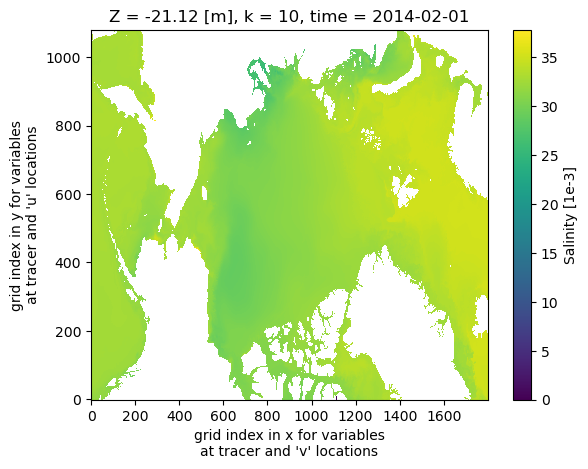

In [54]:
%%time
data["SALT"].isel(time=0, k=10).plot()

#### HTTP endpoints

In [67]:
s3_creds = ea.get_s3_credentials(daac="PODAAC")
store_monthly_http = open_local_icechunk_httpstore(fname_store_s3access, "https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/", s3_creds)

  2026-03-24T21:41:24.936947Z  WARN icechunk::storage::object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk/src/storage/object_store.rs:92



In [68]:
%%time
## Use it to open data on Earthdata:
data_http = xr.open_zarr(
    store_monthly_http,
    zarr_format=3,
    consolidated=False,
    chunks={},
)
data_http

CPU times: user 46.6 ms, sys: 8.17 ms, total: 54.8 ms
Wall time: 44.5 ms


/opt/coiled/env/lib/python3.13/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


<xarray.Dataset> Size: 124GB
Dimensions:   (time: 85, j: 1080, i: 1800, k: 90, i_g: 1800, j_g: 1080, nb: 4,
               k_u: 90, k_l: 90, k_p1: 91, nv: 2)
Coordinates: (12/22)
    XC        (j, i) float32 8MB dask.array<chunksize=(1080, 1800), meta=np.ndarray>
    YC_bnds   (j, i, nb) float32 31MB dask.array<chunksize=(1080, 1800, 4), meta=np.ndarray>
    XV        (j_g, i) float32 8MB dask.array<chunksize=(1080, 1800), meta=np.ndarray>
    Zu        (k_u) float32 360B dask.array<chunksize=(90,), meta=np.ndarray>
    YU        (j, i_g) float32 8MB dask.array<chunksize=(1080, 1800), meta=np.ndarray>
    Z         (k) float32 360B dask.array<chunksize=(90,), meta=np.ndarray>
    ...        ...
  * k_p1      (k_p1) int32 364B 0 1 2 3 4 5 6 7 8 ... 82 83 84 85 86 87 88 89 90
  * i_g       (i_g) int32 7kB 0 1 2 3 4 5 6 ... 1794 1795 1796 1797 1798 1799
    Z_bnds    (k, nv) float32 720B dask.array<chunksize=(90, 2), meta=np.ndarray>
  * time      (time) datetime64[ns] 680B 2014-02-01 2014-03-01 ... 2021-02-01
  * k_u       (k_u) int32 360B 0 1 2 3 4 5 6 7 8 ... 81 82 83 84 85 86 87 88 89
  * k         (k) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
Dimensions without coordinates: nb, nv
Data variables:
    ETAN      (time, j, i) float32 661MB dask.array<chunksize=(1, 1080, 1800), meta=np.ndarray>
    PHIBOT    (time, j, i) float32 661MB dask.array<chunksize=(1, 1080, 1800), meta=np.ndarray>
    SALT      (time, k, j, i) float32 59GB dask.array<chunksize=(1, 15, 270, 450), meta=np.ndarray>
    SIheff    (time, j, i) float32 661MB dask.array<chunksize=(1, 1080, 1800), meta=np.ndarray>
    SIuice    (time, j, i_g) float32 661MB dask.array<chunksize=(1, 1080, 1800), meta=np.ndarray>
    SIarea    (time, j, i) float32 661MB dask.array<chunksize=(1, 1080, 1800), meta=np.ndarray>
    THETA     (time, k, j, i) float32 59GB dask.array<chunksize=(1, 15, 270, 450), meta=np.ndarray>
    SIvice    (time, j_g, i) float32 661MB dask.array<chunksize=(1, 1080, 1800), meta=np.ndarray>
    SIhsnow   (time, j, i) float32 661MB dask.array<chunksize=(1, 1080, 1800), meta=np.ndarray>
    sIceLoad  (time, j, i) float32 661MB dask.array<chunksize=(1, 1080, 1800), meta=np.ndarray>
Attributes: (12/49)
    acknowledgement:                   This research was carried out by the J...
    author:                            Marie Zahn, Mike Wood, Ian Fenty, and ...
    cdm_data_type:                     Grid
    Conventions:                       CF-1.8, ACDD-1.3
    creator_email:                     marie.j.zahn@jpl.nasa.gov
    creator_institution:               NASA Jet Propulsion Laboratory (JPL)
    ...                                ...
    geospatial_vertical_min:           -7000.0
    geospatial_vertical_positive:      up
    geospatial_vertical_resolution:    variable
    geospatial_vertical_units:         meter
    identifier_product_doi:            https://doi.org/10.5067/SEL1D-DUG11
    date_created:                      2026-03-21T00:00:00Z

In [69]:
%%time
data_http["SALT"].isel(time=0, k=10).plot()

CPU times: user 38.5 ms, sys: 8.04 ms, total: 46.5 ms
Wall time: 109 ms


IcechunkError:   x no virtual chunk container can handle the chunk location (s3://podaac-ops-cumulus-protected/SASSIE_ECCO_L4_TEMP_SALINITY_LLC1080GRID_SNAPSHOT_V1R1/OCEAN_TEMPERATURE_SALINITY_month_snap_2014-02-
  | 01_SASSIE_ECCO_V1R1_native_llc1080.nc), edit the repository configuration adding a virtual chunk container for the chunk references, see https://icechunk.io/en/stable/virtual/
  | 
  | context:
  |    0: icechunk::store::get
  |            with key="Z/c/0" byte_range=From(0)
  |              at icechunk/src/store.rs:198
  | 
  `-> no virtual chunk container can handle the chunk location (s3://podaac-ops-cumulus-protected/SASSIE_ECCO_L4_TEMP_SALINITY_LLC1080GRID_SNAPSHOT_V1R1/OCEAN_TEMPERATURE_SALINITY_month_snap_2014-
      02-01_SASSIE_ECCO_V1R1_native_llc1080.nc), edit the repository configuration adding a virtual chunk container for the chunk references, see https://icechunk.io/en/stable/virtual/


## 4.2 Daily averages

#### S3 endpoints

In [13]:
s3_creds = ea.get_s3_credentials(daac="PODAAC")
bucket = 'podaac-ops-cumulus-protected'
store_daily = open_local_icechunk_s3store(fname_store_s3access_daily, "s3://"+bucket, s3_creds)

  2026-03-26T00:04:42.257520Z  WARN icechunk::storage::object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk/src/storage/object_store.rs:92



In [14]:
%%time
## Use it to open data on Earthdata:
data = xr.open_zarr(
    store_daily,
    zarr_format=3,
    consolidated=False,
    chunks={},
)
data

/opt/coiled/env/lib/python3.13/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


CPU times: user 717 ms, sys: 141 ms, total: 859 ms
Wall time: 1.03 s


<xarray.Dataset> Size: 46TB
Dimensions:    (time: 2581, k_l: 90, j: 1080, i: 1800, k: 90, i_g: 1800,
                j_g: 1080, k_u: 90, nb: 4, nv: 2, k_p1: 91)
Coordinates: (12/23)
    XU         (j, i_g) float32 8MB dask.array<chunksize=(1080, 1800), meta=np.ndarray>
    XC         (j, i) float32 8MB dask.array<chunksize=(1080, 1800), meta=np.ndarray>
    XV         (j_g, i) float32 8MB dask.array<chunksize=(1080, 1800), meta=np.ndarray>
    XC_bnds    (j, i, nb) float32 31MB dask.array<chunksize=(1080, 1800, 4), meta=np.ndarray>
  * i          (i) int32 7kB 0 1 2 3 4 5 6 ... 1794 1795 1796 1797 1798 1799
  * i_g        (i_g) int32 7kB 0 1 2 3 4 5 6 ... 1794 1795 1796 1797 1798 1799
    ...         ...
  * k_p1       (k_p1) int32 364B 0 1 2 3 4 5 6 7 8 ... 83 84 85 86 87 88 89 90
  * k_l        (k_l) int32 360B 0 1 2 3 4 5 6 7 8 ... 81 82 83 84 85 86 87 88 89
  * time       (time) datetime64[ns] 21kB 2014-01-15T12:00:00 ... 2021-02-07T...
    time_bnds  (time, nv) datetime64[ns] 41kB dask.array<chunksize=(1, 2), meta=np.ndarray>
  * k          (k) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * j_g        (j_g) int32 4kB 0 1 2 3 4 5 6 ... 1074 1075 1076 1077 1078 1079
Dimensions without coordinates: nb, nv
Data variables: (12/71)
    ADVr_SLT   (time, k_l, j, i) float32 2TB dask.array<chunksize=(1, 15, 270, 450), meta=np.ndarray>
    ADVx_TH    (time, k, j, i_g) float32 2TB dask.array<chunksize=(1, 15, 270, 450), meta=np.ndarray>
    ADVr_TH    (time, k_l, j, i) float32 2TB dask.array<chunksize=(1, 15, 270, 450), meta=np.ndarray>
    ADVy_TH    (time, k, j_g, i) float32 2TB dask.array<chunksize=(1, 15, 270, 450), meta=np.ndarray>
    EXFaqh     (time, j, i) float32 20GB dask.array<chunksize=(1, 1080, 1800), meta=np.ndarray>
    ADVy_SLT   (time, k, j_g, i) float32 2TB dask.array<chunksize=(1, 15, 270, 450), meta=np.ndarray>
    ...         ...
    oceFWflx   (time, j, i) float32 20GB dask.array<chunksize=(1, 1080, 1800), meta=np.ndarray>
    oceTAUY    (time, j_g, i) float32 20GB dask.array<chunksize=(1, 1080, 1800), meta=np.ndarray>
    oceQnet    (time, j, i) float32 20GB dask.array<chunksize=(1, 1080, 1800), meta=np.ndarray>
    oceQsw     (time, j, i) float32 20GB dask.array<chunksize=(1, 1080, 1800), meta=np.ndarray>
    sIceLoad   (time, j, i) float32 20GB dask.array<chunksize=(1, 1080, 1800), meta=np.ndarray>
    oceTAUX    (time, j, i_g) float32 20GB dask.array<chunksize=(1, 1080, 1800), meta=np.ndarray>
Attributes: (12/49)
    acknowledgement:                   This research was carried out by the J...
    author:                            Marie Zahn, Mike Wood, Ian Fenty, and ...
    cdm_data_type:                     Grid
    Conventions:                       CF-1.8, ACDD-1.3
    creator_email:                     marie.j.zahn@jpl.nasa.gov
    creator_institution:               NASA Jet Propulsion Laboratory (JPL)
    ...                                ...
    geospatial_vertical_min:           -7000.0
    geospatial_vertical_positive:      up
    geospatial_vertical_resolution:    variable
    geospatial_vertical_units:         meter
    identifier_product_doi:            https://doi.org/10.5067/SEL1D-DUG11
    date_created:                      2026-03-21T00:00:00Z

CPU times: user 940 ms, sys: 247 ms, total: 1.19 s
Wall time: 648 ms


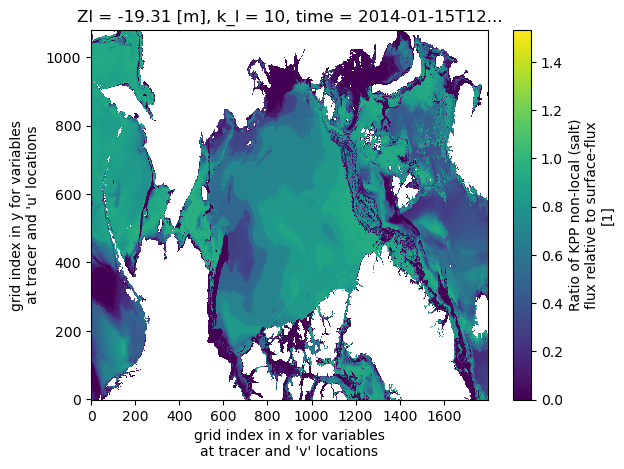

In [16]:
%%time
data["KPPghatK"].isel(time=0, k_l=10).plot()

CPU times: user 997 ms, sys: 146 ms, total: 1.14 s
Wall time: 642 ms


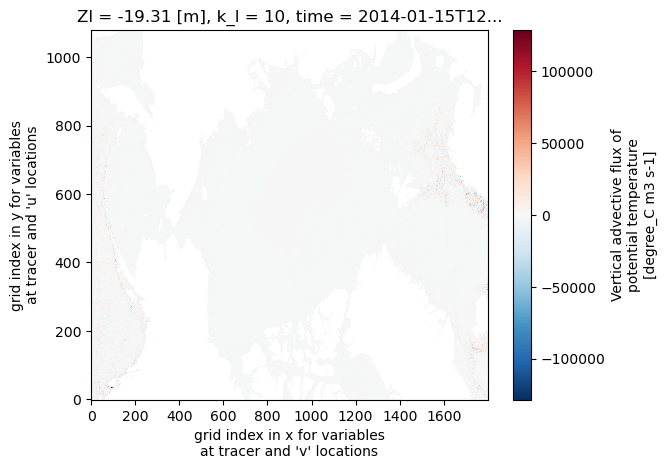

In [18]:
%%time
data["ADVr_TH"].isel(time=0, k_l=10).plot()

CPU times: user 1min 51s, sys: 19.6 s, total: 2min 10s
Wall time: 41.7 s


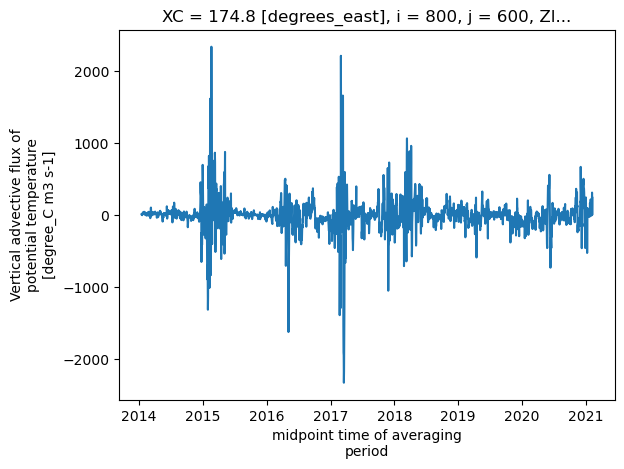

In [17]:
%%time
data["ADVr_TH"].isel(k_l=10, j=600, i=800).plot()